# BlueStock Mutual Fund Capstone

# Day 6 - Advanced Analytics

## Tasks

- Historical VaR (95%)
- Historical CVaR
- Rolling 90-Day Sharpe
- Investor Cohort Analysis
- SIP Continuity Analysis
- Fund Recommendation System
- Sector HHI Concentration
- Advanced Business Insights

In [59]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)
pd.set_option("display.width",200)

In [60]:
# ==========================
# PROJECT PATHS
# ==========================

BASE_DIR = Path("../")

PROCESSED = BASE_DIR/"data"/"processed"



VISUALS = BASE_DIR/"visuals"

SCRIPTS = BASE_DIR/"scripts"

ADVANCED = BASE_DIR / "data" / "advanced"

ADVANCED.mkdir(
    parents=True,
    exist_ok=True
)

VISUALS.mkdir(
    parents=True,
    exist_ok=True
)

SCRIPTS.mkdir(
    parents=True,
    exist_ok=True
)

In [61]:
performance = pd.read_csv(
    PROCESSED/"07_scheme_performance_clean.csv"
)

transactions = pd.read_csv(
    PROCESSED/"08_investor_transactions_clean.csv"
)

nav = pd.read_csv(
    PROCESSED/"02_nav_history_clean.csv"
)

holdings = pd.read_csv(
    PROCESSED/"09_portfolio_holdings_clean.csv"
)

In [62]:
print(performance.shape)

print(transactions.shape)

print(nav.shape)

print(holdings.shape)

(40, 19)
(32778, 13)
(64320, 3)
(322, 8)


In [63]:
print(nav.columns)

print(performance.columns)

print(transactions.columns)

print(holdings.columns)

Index(['date', 'amfi_code', 'nav'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade'],
      dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status'], dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date'], dtype='str')


In [64]:
nav["date"]=pd.to_datetime(
    nav["date"]
)

nav["amfi_code"]=(
    nav["amfi_code"]
    .astype(int)
)

nav=nav.sort_values(
    [
        "amfi_code",
        "date"
    ]
)

nav.head()

,date,amfi_code,nav
1608,2022-01-03,100016,520.4608
1609,2022-01-04,100016,515.0971
1610,2022-01-05,100016,521.7239
1611,2022-01-06,100016,515.7880
1612,2022-01-07,100016,515.1639


In [65]:
nav["daily_return"]=(
    nav
    .groupby(
        "amfi_code"
    )["nav"]
    .pct_change()
)

In [66]:
nav.head()

,date,amfi_code,nav,daily_return
1608,2022-01-03,100016,520.4608,NaN
1609,2022-01-04,100016,515.0971,-0.010306
1610,2022-01-05,100016,521.7239,0.012865
1611,2022-01-06,100016,515.7880,-0.011377
1612,2022-01-07,100016,515.1639,-0.001210


In [67]:
records=[]

for code,df in nav.groupby("amfi_code"):

    returns=df["daily_return"].dropna()

    if len(returns)<30:
        continue

    var95=np.percentile(
        returns,
        5
    )

    cvar95=returns[
        returns<=var95
    ].mean()

    records.append({

        "amfi_code":code,

        "VaR_95":var95,

        "CVaR_95":cvar95

    })

In [68]:
var_report=pd.DataFrame(
    records
)

print(var_report.shape)

var_report.head()

(40, 3)


,amfi_code,VaR_95,CVaR_95
0,100016,-0.012884,-0.016768
1,100025,-0.003338,-0.004581
2,100033,-0.016902,-0.021850
3,101206,-0.012173,-0.016075
4,101207,-0.023915,-0.030289


In [69]:
print(var_report.shape)

(40, 3)


In [70]:
performance["amfi_code"] = (
    performance["amfi_code"]
    .astype(int)
)

var_report = var_report.merge(

    performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "risk_grade"
        ]
    ],

    on="amfi_code",

    how="left"

)

In [71]:
var_report = var_report[
[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "category",
    "risk_grade",
    "VaR_95",
    "CVaR_95"
]
]

var_report.head()

,amfi_code,scheme_name,fund_house,category,risk_grade,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Moderate,-0.012884,-0.016768
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Low,-0.003338,-0.004581
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,High,-0.016902,-0.021850
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,Moderate,-0.012173,-0.016075
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Very High,-0.023915,-0.030289


In [72]:
var_report = var_report.sort_values(
    "VaR_95"
)

var_report.reset_index(
    drop=True,
    inplace=True
)

In [73]:
var_report.to_csv(

    ADVANCED/
    "var_cvar_report.csv",

    index=False

)

print(
    "✅ var_cvar_report.csv Saved"
)

✅ var_cvar_report.csv Saved


In [74]:
print(var_report.describe())

           amfi_code     VaR_95    CVaR_95
count      40.000000  40.000000  40.000000
mean   120247.000000  -0.013184  -0.017243
std     14534.998667   0.006103   0.007888
min    100016.000000  -0.023915  -0.030289
25%    118632.750000  -0.016786  -0.021556
50%    119551.500000  -0.012788  -0.016866
75%    120842.250000  -0.012006  -0.015469
max    149324.000000  -0.000196  -0.000325


In [75]:
rolling_data = nav.copy()

In [76]:
rolling_data["rolling_mean"] = (

    rolling_data

    .groupby("amfi_code")

    ["daily_return"]

    .transform(

        lambda x:

        x.rolling(90).mean()

    )

)

In [77]:
rolling_data["rolling_std"] = (

    rolling_data

    .groupby("amfi_code")

    ["daily_return"]

    .transform(

        lambda x:

        x.rolling(90).std()

    )

)

In [78]:
rolling_data["rolling_sharpe"] = (

    rolling_data["rolling_mean"]

    /

    rolling_data["rolling_std"]

) * np.sqrt(252)

In [79]:
rolling_data.head()

,date,amfi_code,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
1608,2022-01-03,100016,520.4608,NaN,NaN,NaN,NaN
1609,2022-01-04,100016,515.0971,-0.010306,NaN,NaN,NaN
1610,2022-01-05,100016,521.7239,0.012865,NaN,NaN,NaN
1611,2022-01-06,100016,515.7880,-0.011377,NaN,NaN,NaN
1612,2022-01-07,100016,515.1639,-0.001210,NaN,NaN,NaN


In [80]:
# ==========================================
# Select Top 5 Funds
# ==========================================

top5 = performance.sort_values(

    "aum_crore",

    ascending=False

).head(5)

top5_codes = top5["amfi_code"].tolist()

top5_codes

[148568, 120842, 118634, 149322, 102886]

In [81]:
# ==========================================
# Filter Rolling Data
# ==========================================

plot_data = rolling_data[

    rolling_data["amfi_code"].isin(

        top5_codes

    )

]

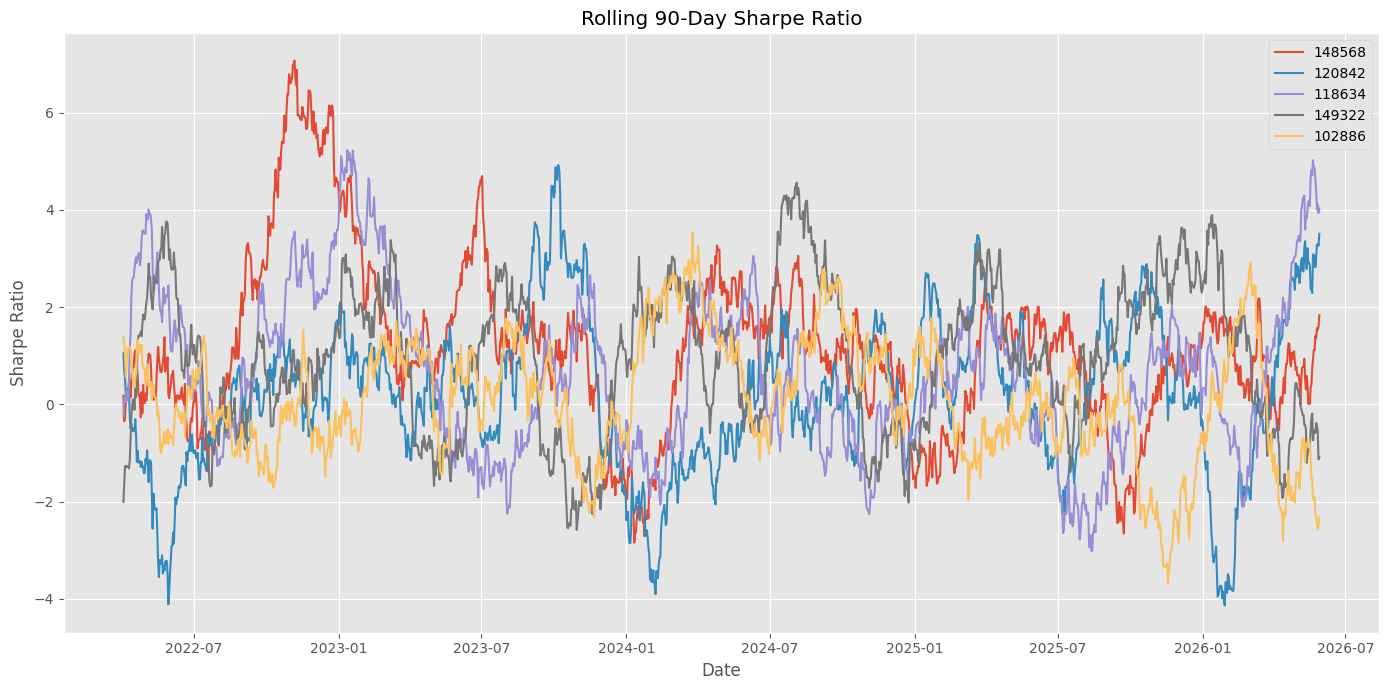

In [82]:
# ==========================================
# Rolling 90-Day Sharpe Plot
# ==========================================

fig, ax = plt.subplots(figsize=(14,7))

for code in top5_codes:

    df = plot_data[
        plot_data["amfi_code"] == code
    ]

    ax.plot(
        df["date"],
        df["rolling_sharpe"],
        label=str(code)
    )

ax.set_title("Rolling 90-Day Sharpe Ratio")

ax.set_xlabel("Date")

ax.set_ylabel("Sharpe Ratio")

ax.legend()

ax.grid(True)

fig.tight_layout()

fig.savefig(
    VISUALS/"rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
print(plot_data.shape)

(8040, 7)


In [84]:
# ==========================================
# INVESTOR COHORT ANALYSIS
# ==========================================

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [85]:
# First investment date of every investor

first_txn = (

    transactions

    .groupby("investor_id")["transaction_date"]

    .min()

    .reset_index()

)

first_txn.columns = [

    "investor_id",

    "first_transaction"

]

first_txn.head()

,investor_id,first_transaction
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [86]:
# Cohort Year

first_txn["cohort_year"] = (

    first_txn["first_transaction"]

    .dt.year

)

first_txn.head()

,investor_id,first_transaction,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [87]:
# Merge cohort back

transactions = transactions.merge(

    first_txn[

        [

            "investor_id",

            "cohort_year"

        ]

    ],

    on="investor_id",

    how="left"

)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [88]:
# Average SIP amount

avg_sip = (

    transactions

    .groupby(

        "cohort_year"

    )["amount_inr"]

    .mean()

    .reset_index()

)

avg_sip.columns = [

    "cohort_year",

    "average_sip"

]

avg_sip

,cohort_year,average_sip
0,2024,107422.541832
1,2025,109158.577061


In [89]:
# Total invested

total_invested = (

    transactions

    .groupby(

        "cohort_year"

    )["amount_inr"]

    .sum()

    .reset_index()

)

total_invested.columns = [

    "cohort_year",

    "total_invested"

]

total_invested

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [90]:
# Top preferred fund

top_pref = (

    transactions

    .groupby(

        [

            "cohort_year",

            "amfi_code"

        ]

    )

    .size()

    .reset_index(name="count")

)

In [91]:
top_pref = (

    top_pref

    .sort_values(

        [

            "cohort_year",

            "count"

        ],

        ascending=[True,False]

    )

    .drop_duplicates(

        "cohort_year"

    )

)

top_pref.head()

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [92]:
# Merge scheme names

top_pref = top_pref.merge(

    performance[

        [

            "amfi_code",

            "scheme_name"

        ]

    ],

    on="amfi_code",

    how="left"

)

top_pref.head()

,cohort_year,amfi_code,count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [93]:
# Final Cohort Summary

cohort_summary = (

    avg_sip

    .merge(

        total_invested,

        on="cohort_year"

    )

    .merge(

        top_pref[

            [

                "cohort_year",

                "scheme_name"

            ]

        ],

        on="cohort_year"

    )

)

cohort_summary

,cohort_year,average_sip,total_invested,scheme_name
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,SBI Small Cap Fund - Direct Plan - Growth


In [94]:
cohort_summary.to_csv(

    ADVANCED/

    "cohort_analysis.csv",

    index=False

)

print(

    "✅ Cohort Analysis Saved"

)

✅ Cohort Analysis Saved


In [95]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [96]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [97]:
# ==========================================
# SECTOR HHI CONCENTRATION ANALYSIS
# ==========================================

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [98]:
holdings["weight_decimal"] = (

    holdings["weight_pct"]

    /100

)

In [99]:
hhi = (

    holdings

    .groupby("amfi_code")

    ["weight_decimal"]

    .apply(

        lambda x:(x**2).sum()

    )

    .reset_index()

)

hhi.columns=[

    "amfi_code",

    "HHI"

]

In [100]:
hhi = hhi.merge(

    performance[

        [

            "amfi_code",

            "scheme_name",

            "category",

            "risk_grade"

        ]

    ],

    on="amfi_code",

    how="left"

)

In [101]:
hhi = hhi.sort_values(

    "HHI",

    ascending=False

)

hhi.head()

,amfi_code,HHI,scheme_name,category,risk_grade
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Large Cap,Moderate
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Small Cap,Very High
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,Very High
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Index,Moderate
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Large Cap,Moderate


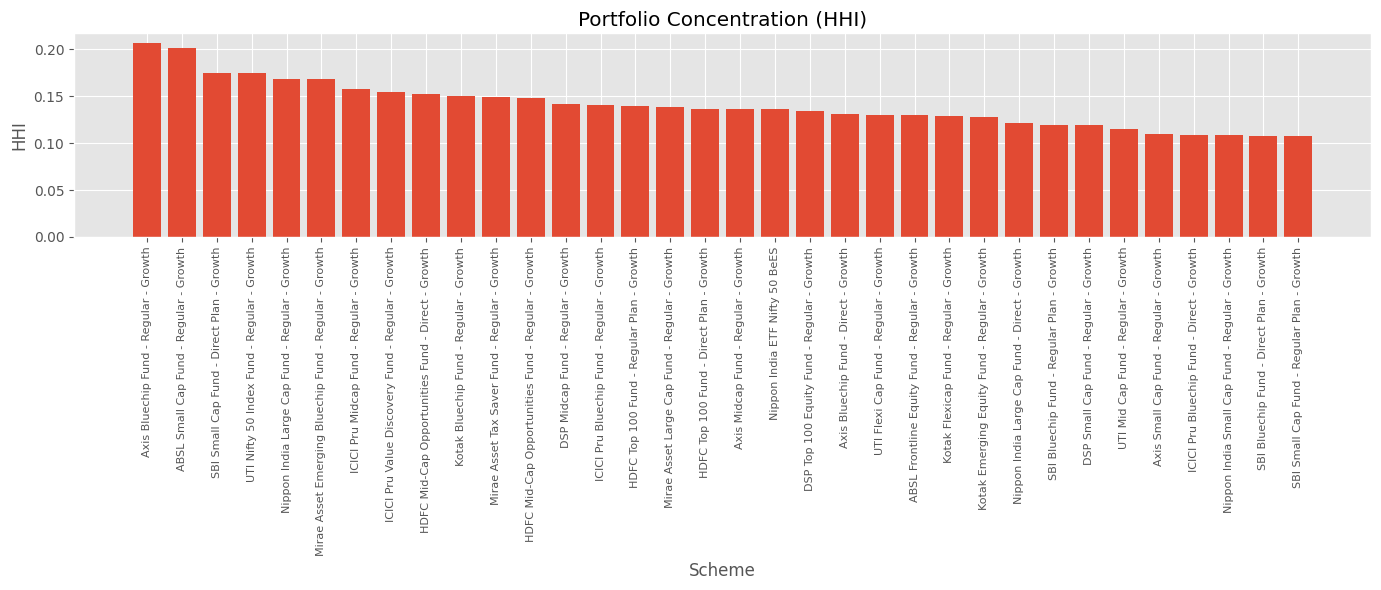

In [102]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14,6))

ax.bar(
    hhi["scheme_name"],
    hhi["HHI"]
)

ax.set_title("Portfolio Concentration (HHI)")
ax.set_xlabel("Scheme")
ax.set_ylabel("HHI")

plt.xticks(rotation=90, fontsize=8)

fig.tight_layout()

fig.savefig(
    VISUALS/"hhi_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
plt.savefig(

    VISUALS/

    "hhi_concentration.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

<Figure size 640x480 with 0 Axes>

In [104]:
hhi.to_csv(

    ADVANCED/

    "hhi_report.csv",

    index=False

)

print(

"✅ HHI Report Saved"

)

✅ HHI Report Saved


In [105]:
# ==========================================
# SIP CONTINUITY ANALYSIS
# ==========================================

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [106]:
# ==========================================
# SIP CONTINUITY ANALYSIS
# ==========================================

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [107]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions = transactions.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

In [108]:
sip = (

    transactions

    .groupby("investor_id")

    .filter(

        lambda x: len(x) >= 6

    )

)

print(sip.shape)

(26616, 14)


In [109]:
gap_records = []

In [110]:
for investor, df in sip.groupby("investor_id"):

    df = df.sort_values(
        "transaction_date"
    )

    gaps = (

        df["transaction_date"]

        .diff()

        .dt.days

        .dropna()

    )

    avg_gap = gaps.mean()

    gap_records.append({

        "investor_id": investor,

        "num_transactions": len(df),

        "avg_gap_days": avg_gap

    })

In [111]:
gap_df = pd.DataFrame(
    gap_records
)

gap_df.head()

,investor_id,num_transactions,avg_gap_days
0,INV000002,6,82.800000
1,INV000004,9,53.375000
2,INV000005,8,52.000000
3,INV000006,6,99.000000
4,INV000008,8,50.285714


In [112]:
gap_df["status"] = np.where(

    gap_df["avg_gap_days"] > 35,

    "At-Risk",

    "Healthy"

)


gap_df.head()

,investor_id,num_transactions,avg_gap_days,status
0,INV000002,6,82.800000,At-Risk
1,INV000004,9,53.375000,At-Risk
2,INV000005,8,52.000000,At-Risk
3,INV000006,6,99.000000,At-Risk
4,INV000008,8,50.285714,At-Risk


In [113]:
gap_df = gap_df.sort_values(

    "avg_gap_days",

    ascending=False

)

gap_df.head(10)

,investor_id,num_transactions,avg_gap_days,status
2508,INV004253,6,100.8,At-Risk
1589,INV002658,6,100.8,At-Risk
2695,INV004548,6,99.8,At-Risk
1620,INV002716,6,99.8,At-Risk
2123,INV003571,6,99.6,At-Risk
625,INV001011,6,99.4,At-Risk
662,INV001068,6,99.2,At-Risk
866,INV001433,6,99.2,At-Risk
3,INV000006,6,99.0,At-Risk
932,INV001560,6,98.2,At-Risk


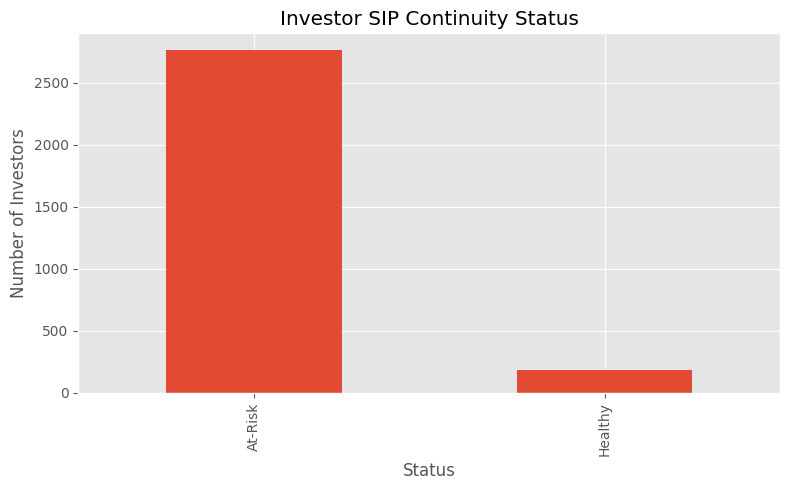

In [114]:
fig, ax = plt.subplots(figsize=(8,5))

gap_df["status"].value_counts().plot(
    kind="bar",
    ax=ax
)

ax.set_title("Investor SIP Continuity Status")
ax.set_xlabel("Status")
ax.set_ylabel("Number of Investors")

fig.tight_layout()

fig.savefig(
    VISUALS/"sip_continuity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [115]:
plt.savefig(

    VISUALS/

    "sip_continuity.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

<Figure size 640x480 with 0 Axes>

In [116]:
gap_df.to_csv(

    ADVANCED/

    "sip_continuity_report.csv",

    index=False

)

print(

"✅ SIP Continuity Report Saved"

)

✅ SIP Continuity Report Saved


# Advanced Business Insights

## Insight 1: Downside Risk

Historical VaR (95%) analysis shows that some schemes have
significantly larger downside risk than others. Investors with
low risk tolerance should prefer schemes with relatively stable
return distributions.

---

## Insight 2: Tail Risk

CVaR values indicate the expected loss beyond the VaR threshold.
Funds with highly negative CVaR values expose investors to larger
losses during adverse market conditions.

---

## Insight 3: Investor Cohorts

Recent investor cohorts contribute a substantial share of total
investments. Understanding cohort behavior helps AMCs design
better retention and marketing strategies.

---

## Insight 4: SIP Continuity

Investors whose average transaction gap exceeds 35 days are
classified as "At-Risk". Early intervention programs can improve
SIP continuation and customer retention.

---

## Insight 5: Portfolio Diversification

HHI analysis shows that highly concentrated portfolios carry
greater sector-specific risk, whereas diversified portfolios
provide better risk distribution and long-term stability.